In [40]:
# ATMS 523 Weather and Climate Data Analytics
# Project 2: dask & xarray for computing weather and climate diagnostics
# ERA-5 Precipitation Analysis

import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import dask
from dask.distributed import Client

# Set up dask client for parallel processing
client = Client()
print(f"Dask dashboard: {client.dashboard_link}")
client


c:\Users\ztors\miniconda3\envs\xarray-climate\Lib\site-packages\distributed\node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 52593 instead
  warnings.warn(


Dask dashboard: http://127.0.0.1:52593/status


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:52593/status,
Dashboard: http://127.0.0.1:52593/status,Workers: 4
Total threads: 8,Total memory: 15.69 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:52594,Workers: 0
Dashboard: http://127.0.0.1:52593/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:52614,Total threads: 2
Dashboard: http://127.0.0.1:52617/status,Memory: 3.92 GiB
Nanny: tcp://127.0.0.1:52597,


In [41]:
# Load the ERA-5 dataset from Google Cloud Platform ARCO
# This dataset contains hourly ERA-5 reanalysis data on a 0.25-degree grid

ds = xr.open_zarr(
    'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3',
    chunks=None,
    storage_options=dict(token='anon'),
)

# Filter to a specific time period for analysis
ds = ds.sel(time=slice(ds.attrs['valid_time_start'], ds.attrs['valid_time_stop']))

ds


<xarray.Dataset> Size: 2PB
Dimensions:                                                          (
                                                                      time: 748008,
                                                                      latitude: 721,
                                                                      longitude: 1440,
                                                                      level: 37)
Coordinates:
  * latitude                                                         (latitude) float32 3kB ...
  * level                                                            (level) int64 296B ...
  * longitude                                                        (longitude) float32 6kB ...
  * time                                                             (time) datetime64[ns] 6MB ...
Data variables: (12/273)
    100m_u_component_of_wind                                         (time, latitude, longitude) float32 3TB ...
    100m_v_component_of_wind                                         (time, latitude, longitude) float32 3TB ...
    10m_u_component_of_neutral_wind                                  (time, latitude, longitude) float32 3TB ...
    10m_u_component_of_wind                                          (time, latitude, longitude) float32 3TB ...
    10m_v_component_of_neutral_wind                                  (time, latitude, longitude) float32 3TB ...
    10m_v_component_of_wind                                          (time, latitude, longitude) float32 3TB ...
    ...                                                               ...
    wave_spectral_directional_width_for_swell                        (time, latitude, longitude) float32 3TB ...
    wave_spectral_directional_width_for_wind_waves                   (time, latitude, longitude) float32 3TB ...
    wave_spectral_kurtosis                                           (time, latitude, longitude) float32 3TB ...
    wave_spectral_peakedness                                         (time, latitude, longitude) float32 3TB ...
    wave_spectral_skewness                                           (time, latitude, longitude) float32 3TB ...
    zero_degree_level                                                (time, latitude, longitude) float32 3TB ...
Attributes:
    last_updated:           2025-09-30 02:21:16.868718+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2025-04-30
    valid_time_stop_era5t:  2025-09-24

In [42]:
# Explore the dataset to find precipitation variables
precip_columns = [var for var in ds.data_vars.keys() if "precip" in var.lower()]
print("\n".join(precip_columns))

convective_precipitation
instantaneous_large_scale_surface_precipitation_fraction
large_scale_precipitation
large_scale_precipitation_fraction
maximum_total_precipitation_rate_since_previous_post_processing
mean_convective_precipitation_rate
mean_large_scale_precipitation_fraction
mean_large_scale_precipitation_rate
mean_total_precipitation_rate
minimum_total_precipitation_rate_since_previous_post_processing
precipitation_type
total_precipitation


per lab instructions, we care about total precipitation

(1) Use the precipitation output of ERA-5 to compute a time series of daily precipitation at a given point closest to a city of your choosing. Choose a box of 5 x 5 deg lat-lon values over the grid box closest to the city you are examining.  Save this data.  Use a period of at least 10 years.

In [43]:
# Check the format of longitude
print(f"Longitude range: {ds.longitude.min().values:.2f} to {ds.longitude.max().values:.2f}")
print(f"Latitude range: {ds.latitude.min().values:.2f} to {ds.latitude.max().values:.2f}")
print(f"Time range: {ds.time.min().values} to {ds.time.max().values}")

Longitude range: 0.00 to 359.75
Latitude range: -90.00 to 90.00
Time range: 1940-01-01T00:00:00.000000000 to 2025-04-30T23:00:00.000000000


In [5]:
# Seattle coordinates according to Google search
seattle_lat = 47.6061  # degrees North
seattle_lon = -122.3328  # degrees West

# Convert to 0-360°
seattle_lon = 360 + seattle_lon

# A 5x5 degree grid extends 2.5 degrees in each direction from Seattle
lat_min = seattle_lat - 2.5  # 45.1061°N
lat_max = seattle_lat + 2.5  # 50.1061°N
lon_min = seattle_lon - 2.5  # 235.1672°
lon_max = seattle_lon + 2.5  # 240.1672°

print(f"Analysis box bounds:")
print(f"  Latitude: {lat_min:.4f}° to {lat_max:.4f}°")
print(f"  Longitude: {lon_min:.4f}° to {lon_max:.4f}°")

# Filter the dataset to our analysis box around Seattle
ds_seattle = ds.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
print(f"\nSeattle region dataset shape: {ds_seattle.dims}")

Analysis box bounds:
  Latitude: 45.1061° to 50.1061°
  Longitude: 235.1672° to 240.1672°

Seattle region dataset shape: FrozenMappingWarningOnValuesAccess({'time': 748008, 'latitude': 0, 'longitude': 20, 'level': 37})


Something went wrong. We got not latitude values. Let's see if latitude is in DESC or ASC.

In [6]:
# Check if latitude coordinates are in ascending or descending order
print(f"\nBegin: {ds.latitude[:1].values}")
print(f"End: {ds.latitude[-1:].values}")


Begin: [90.]
End: [-90.]


Latitude is DESC, so we need to slice backwards.

In [ ]:
# Filter with lat bounds reversed
ds_seattle = ds.sel(latitude=slice(lat_max, lat_min), longitude=slice(lon_min, lon_max))
print(f"\nSeattle region dataset shape: {ds_seattle.dims}")


Seattle region dataset shape: FrozenMappingWarningOnValuesAccess({'time': 748008, 'latitude': 20, 'longitude': 20, 'level': 37})


In [46]:
# Extract and save precipitation data for Seattle region (1991-2020)

import os

filename = 'seattle_precipitation_5x5deg_1991_2020.nc'
if os.path.exists(filename):
    print(f"✓ Found existing file: {filename}")    
    precip_seattle = xr.open_dataset(filename)['total_precipitation']
    
else:
    # Save precipitation data for Seattle region (1991-2020)
    # as NetCDF (preserves all metadata and xarray structure)
    print("File not found locally. Extracting from cloud dataset...")
    precip_seattle = ds_seattle['total_precipitation'].sel(time=slice('1991-01-01', '2020-12-31'))
    precip_seattle.to_netcdf('seattle_precipitation_5x5deg_1991_2020.nc')

✓ Found existing file: seattle_precipitation_5x5deg_1991_2020.nc


(2) Determine the 95% values of daily precipitation for the data created in (1).  Plot a *cumulative distribution function* of all values daily precipitation values and illustrate the 95% value of daily precipitation in millimeters.

Is the data already daily?

In [47]:
print(precip_seattle['time'].values[:5])

['1991-01-01T00:00:00.000000000' '1991-01-01T01:00:00.000000000'
 '1991-01-01T02:00:00.000000000' '1991-01-01T03:00:00.000000000'
 '1991-01-01T04:00:00.000000000']


The data is hourly, so resample to daily.

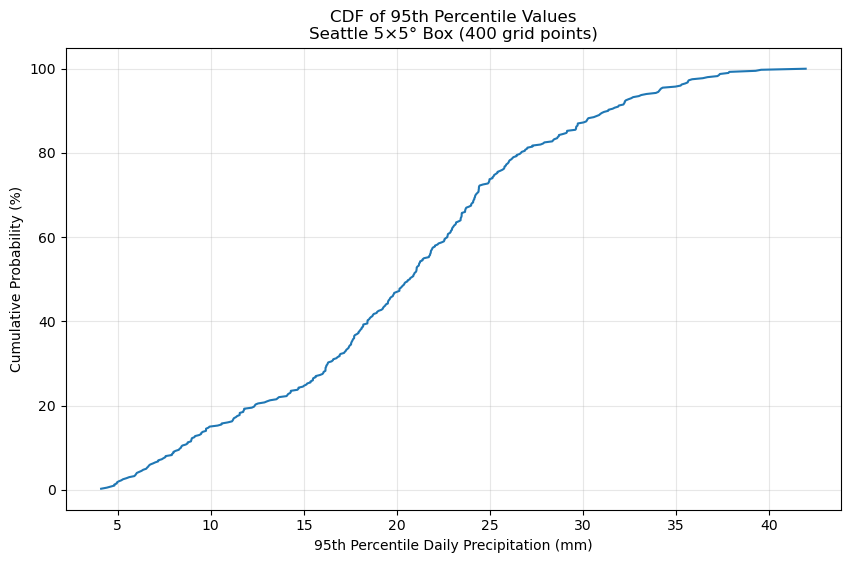

In [48]:
# Convert hourly to daily precipitation totals
daily_precip = precip_seattle.resample(time='1D').sum()

# Convert from meters to millimeters
daily_precip = daily_precip * 1000

# Compute 95th percentile at each grid point across time
# For each point, a value of precipitation that is exceeded 95% of the time
p95_map = daily_precip.quantile(0.95, dim='time')

# All 400 grid point 95th percentiles as an array
p95_values = p95_map.values.flatten()  

# Create CDF of the 95th percentile values
sorted_p95 = np.sort(p95_values)
n = len(sorted_p95)
cdf_probs = np.arange(1, n+1) / n * 100

# Plot CDF
plt.figure(figsize=(10, 6))
plt.plot(sorted_p95, cdf_probs)
plt.xlabel('95th Percentile Daily Precipitation (mm)')
plt.ylabel('Cumulative Probability (%)')
plt.grid(True, alpha=0.3)
plt.title('CDF of 95th Percentile Values\nSeattle 5×5° Box (400 grid points)')
plt.show()

(3) Create a map of the composite mean precipitation on the 95% days identified in (2) over the continental USA, and a map of the anomaly of precipitation from the 1981-2010 mean. This field should be plotted on a Cartopy map centered at your city with a 40 x 40 degree lat-lon range.

In [37]:
# Download the monthly precipitation data for the continental USA provided by S. Nesbitt
filename = 'ERA-5_total_precipitation_monthly-1981-2020.nc'
if os.path.exists(filename):
    print(f"✓ Found existing file: {filename}")
    ds_climo = xr.open_dataset(filename)
else:
    print("File not found locally. Extracting from cloud dataset...")
    ds_climo = xr.open_dataset('https://www.atmos.illinois.edu/~snesbitt/data/ERA-5_total_precipitation_monthly-1981-2020.nc', engine='h5netcdf')
    ds_climo.to_netcdf('ERA-5_total_precipitation_monthly-1981-2020.nc')

ds_climo

✓ Found existing file: ERA-5_total_precipitation_monthly-1981-2020.nc


<xarray.Dataset> Size: 2GB
Dimensions:     (valid_time: 372, latitude: 721, longitude: 1440)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 3kB 1990-01-01T06:00:00 ... 2020-...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      (valid_time) <U4 6kB ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 2GB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-09-22T22:03 GRIB to CDM+CF via cfgrib-0.9.1...

I see longitude is in degrees east, and latitude goes from positive to negative, matching the seattle data.

However, the Seattle data starts in 1991. Let's trim monthly to match.

In [39]:
# Trim monthly data to match Seattle data period (1991-2020)
ds_climo = ds_climo.sel(valid_time=slice('1991-01-01', '2020-12-31'))

howe